Trial 5 Complete [00h 00m 06s]
val_loss: 323.1798095703125

Best val_loss So Far: 323.1798095703125
Total elapsed time: 00h 00m 27s
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 352.2034 - marks_loss: 351.5992 - marks_mae: 15.8643 - pass_accuracy: 0.6503 - pass_loss: 0.6042 - val_loss: 307.8280 - val_marks_loss: 265.9438 - val_marks_mae: 15.0437 - val_pass_accuracy: 0.7750 - val_pass_loss: 0.3671
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 312.2138 - marks_loss: 311.5468 - marks_mae: 14.8308 - pass_accuracy: 0.7058 - pass_loss: 0.6671 - val_loss: 281.6923 - val_marks_loss: 256.0560 - val_marks_mae: 14.8554 - val_pass_accuracy: 0.9000 - val_pass_loss: 0.3431
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 296.2043 - marks_loss: 295.7063 - marks_mae: 14.4091 - pass_accuracy: 0.7586 - pass_loss: 0.4979 - val_loss: 285.5275 - val_marks_loss: 278.1798 - val_marks_mae: 15.0237 - val_pass_accuracy: 0.9000 - val_pass_loss: 0.2955
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 261.7914 - marks_loss: 261.3576 - marks_mae: 13.4824 - pass_accuracy: 0.7303 - pass_loss: 0.4337 - val_loss: 242.6599

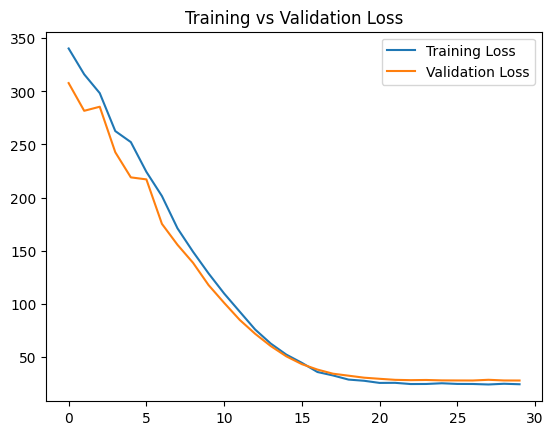

In [ ]:
!pip install keras-tuner

import numpy as np
import tensorflow as tf
import keras_tuner as kt
import matplotlib.pyplot as plt



np.random.seed(42)

study_hours = np.random.uniform(1,10,200)
attendance = np.random.uniform(50,100,200)


X = np.column_stack((study_hours, attendance))


marks = study_hours*8 + attendance*0.3 + np.random.normal(0,5,200)
pass_fail = (marks > 50).astype(int)

Y_marks = marks
Y_pass = pass_fail


def build_model(hp):

    inputs = tf.keras.Input(shape=(2,))

    units = hp.Int('units', min_value=16, max_value=128, step=16)

    x = tf.keras.layers.Dense(units, activation='relu')(inputs)

    marks_output = tf.keras.layers.Dense(1, name="marks")(x)

    pass_output = tf.keras.layers.Dense(1, activation='sigmoid', name="pass")(x)

    model = tf.keras.Model(inputs=inputs, outputs=[marks_output, pass_output])

    lr = hp.Choice('learning_rate', [0.01, 0.001, 0.0001])

    model.compile(
            optimizer=tf.keras.optimizers.Adam(lr),
                    loss={
                                "marks":"mse",
                                            "pass":"binary_crossentropy"
                                    },
                                            metrics={
                                                "marks":"mae",
                                                            "pass":"accuracy"
                                                    }
                                                        )

    return model



tuner = kt.RandomSearch(
    build_model,
        objective='val_loss',
            max_trials=5,
                directory='mimo_tuning',
                    project_name='experiment5'
                    )

tuner.search(
    X,
        {"marks":Y_marks, "pass":Y_pass},
            epochs=20,
                validation_split=0.2
                )

best_model = tuner.get_best_models(num_models=1)[0]



history = best_model.fit(
    X,
        {"marks":Y_marks, "pass":Y_pass},
            epochs=30,
                validation_split=0.2
                )



sample = np.array([[6,85]])

pred_marks, pred_pass = best_model.predict(sample)

print("\nPredicted Marks:", pred_marks[0][0])
print("Pass Probability:", pred_pass[0][0])




plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()